In [109]:
from pathlib import Path

from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore, get_types_from_msg

import pandas as pd
import matplotlib.pyplot as plt

bag_path = Path("../../sensor_core_bag")
# bag_path = Path("../../current_control_bag")
typestore = get_typestore(Stores.ROS2_HUMBLE)


In [110]:
vesc_state_name = "vesc_msgs/msg/VescState"
vesc_state_def = '''
    int32 FAULT_CODE_NONE=0
    int32 FAULT_CODE_OVER_VOLTAGE=1
    int32 FAULT_CODE_UNDER_VOLTAGE=2
    int32 FAULT_CODE_DRV8302=3
    int32 FAULT_CODE_ABS_OVER_CURRENT=4
    int32 FAULT_CODE_OVER_TEMP_FET=5
    int32 FAULT_CODE_OVER_TEMP_MOTOR=6

    float64 temp_fet
    float64 temp_motor
    float64 current_motor
    float64 current_input     
    float64 avg_id
    float64 avg_iq
    float64 duty_cycle
    float64 speed

    float64 voltage_input
    float64 charge_drawn
    float64 charge_regen
    float64 energy_drawn
    float64 energy_regen
    int32   displacement
    int32   distance_traveled
    int32   fault_code

    float64 pid_pos_now
    int32 controller_id


    float64 ntc_temp_mos1
    float64 ntc_temp_mos2
    float64 ntc_temp_mos3
    float64 avg_vd
    float64 avg_vq
'''

vesc_state_stamped_name = "vesc_msgs/msg/VescStateStamped"
vesc_state_stamped_def = '''
    std_msgs/Header  header
    VescState state
'''

In [111]:
parsed_types = get_types_from_msg(vesc_state_def, vesc_state_name)
typestore.register(parsed_types)
parsed_types = get_types_from_msg(vesc_state_stamped_def, vesc_state_stamped_name)
typestore.register(parsed_types)

data = []

with AnyReader([bag_path], default_typestore=typestore) as reader:
    connections = [x for x in reader.connections if x.topic == '/sensors/core']
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)
        
        # print(msg.state)
        data.append(
            {
                "ts": timestamp,
                "current_motor": msg.state.current_motor,
                "current_input": msg.state.current_input,
                "duty_cycle": msg.state.duty_cycle,
                "speed": msg.state.speed,
                "voltage_input": msg.state.voltage_input,
            }
        )




In [112]:
df = pd.DataFrame(data)
# df = df.iloc[900:3900]

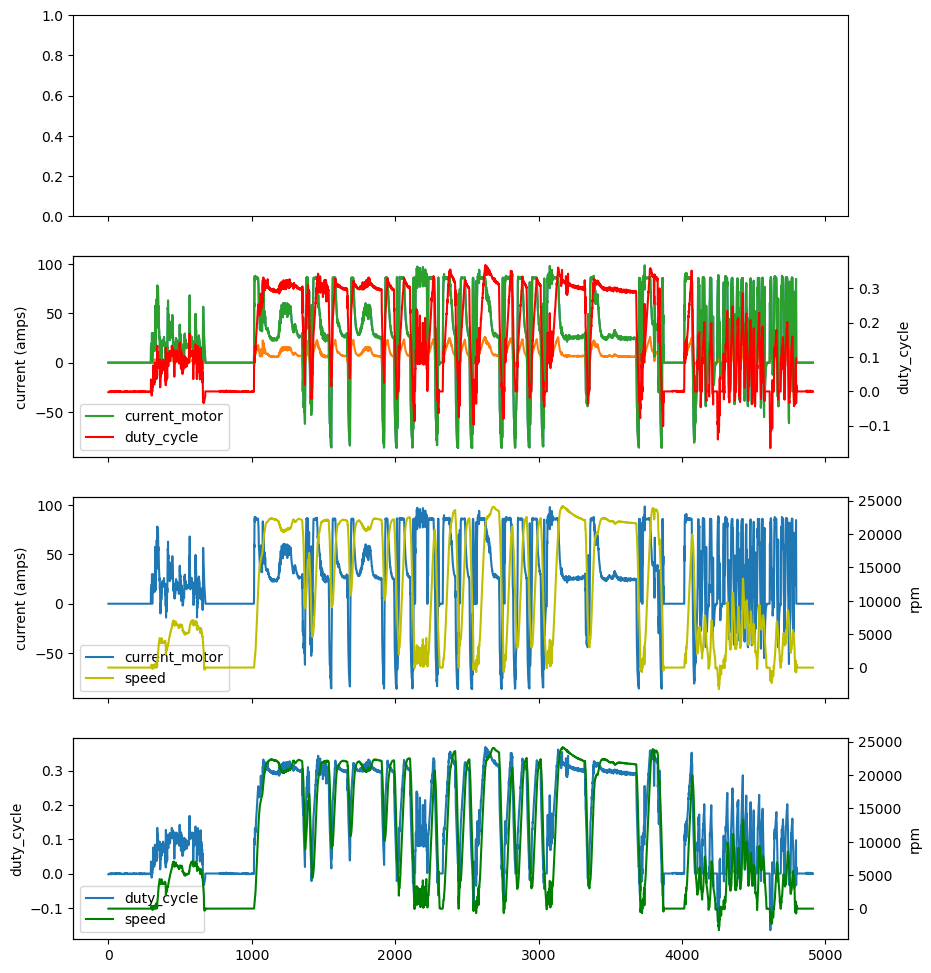

In [113]:
fig, (ax1, ax1, ax2, ax3) = plt.subplots(4, 1, sharex=True, figsize=(10,12))


ax1.plot(df.index, df["current_motor"], label="current_motor")
ax1.plot(df.index, df["current_input"], label="current_input")

ax1.set_ylabel("current (amps)")
ax1.legend()


p1, = ax1.plot(df.index, df["current_motor"], label="current_motor")
twin2 = ax1.twinx()
p2, = twin2.plot(df.index, df["duty_cycle"], "r-", label="duty_cycle")

ax1.set_ylabel("current (amps)")
twin2.set_ylabel("duty_cycle")

ax1.legend(handles=[p1, p2])


p1, = ax2.plot(df.index, df["current_motor"], label="current_motor")
twin3 = ax2.twinx()
p2, = twin3.plot(df.index, df["speed"], "y-", label="speed")

ax2.set_ylabel("current (amps)")
twin3.set_ylabel("rpm")

ax2.legend(handles=[p1, p2])


p1, = ax3.plot(df.index, df["duty_cycle"], label="duty_cycle")
twin4 = ax3.twinx()
p2, = twin4.plot(df.index, df["speed"], "g-", label="speed")

ax3.set_ylabel("duty_cycle")
twin4.set_ylabel("rpm")

ax3.legend(handles=[p1, p2], loc="lower left")

Text(0, 0.5, 'duty_cycle')

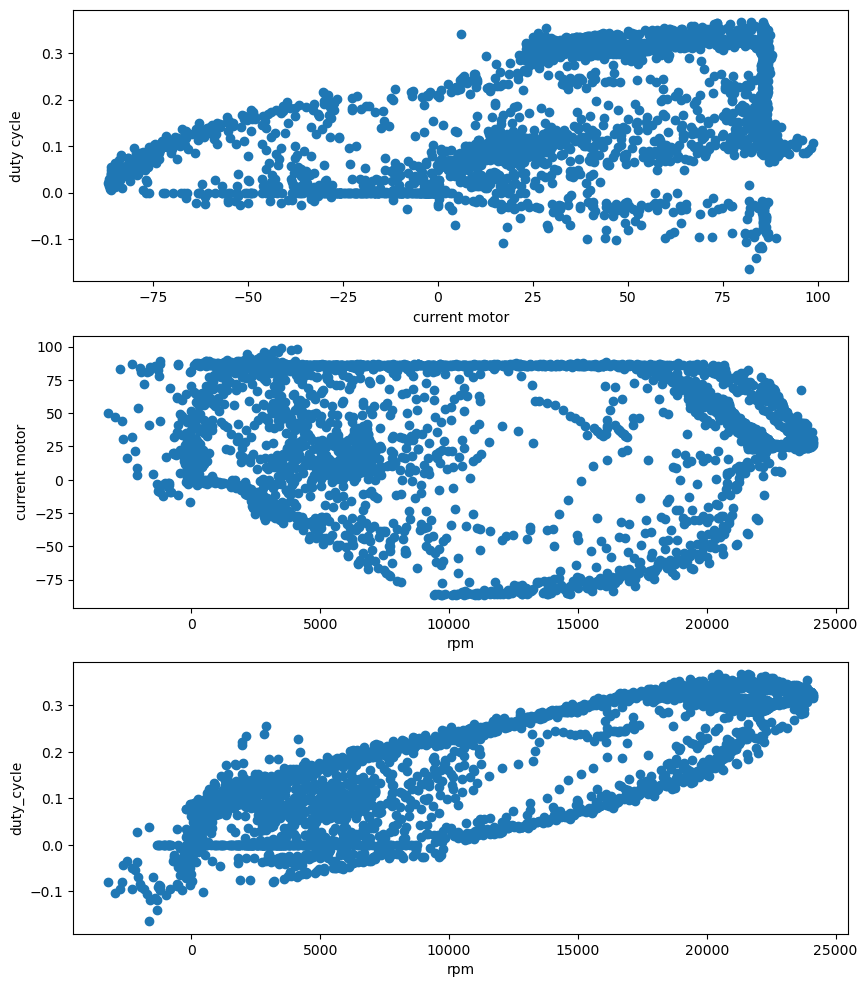

In [114]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(10,12))


ax1.scatter(df["current_motor"], df["duty_cycle"])

ax1.set_xlabel("current motor")
ax1.set_ylabel("duty cycle")


ax2.scatter(df["speed"], df["current_motor"])

ax2.set_xlabel("rpm")
ax2.set_ylabel("current motor")


ax3.scatter(df["speed"], df["duty_cycle"])

ax3.set_xlabel("rpm")
ax3.set_ylabel("duty_cycle")

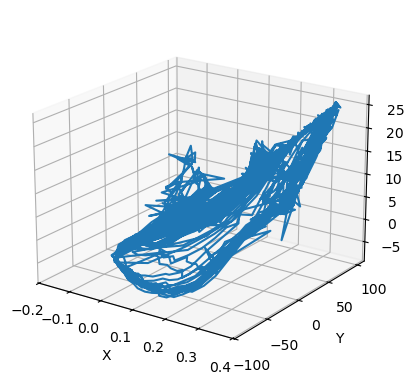

In [115]:
ax = plt.figure().add_subplot(projection='3d')

ax.plot(df['duty_cycle'], df['current_motor'], zs=df['current_input'])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-55, roll=0)

plt.show()